# 05 — True irregular-time ablation (optimized CPU version)

This is the optimized version of Notebook 05.

The scientific question and information boundary are unchanged:

> **Does preserving the original irregular ICU observation times help, compared with the hourly-binned representation?**

The previous implementation was correct in spirit but computationally inefficient on CPU because it called `torchdiffeq.odeint` **once per patient**. On the executed run this cost about 370–394 seconds per epoch.

This version makes two engineering changes **without returning to hourly binning**:

1. **Batched irregular-time RK4 integration.**  
   Every patient still follows its own exact event times. The autonomous ODE is advanced for the whole mini-batch at once, using each patient's own `dt`. Long intervals are subdivided so that each RK4 substep is at most `MAX_RK4_STEP` hours.

2. **Crash-safe checkpoints.**  
   Development training writes a latest-state checkpoint after every epoch and a best-model checkpoint whenever validation AUPRC improves. If the kernel dies, rerunning the notebook resumes development automatically. Final all-A training is checkpointed as well.

The previous interrupted run is **not resumed**, because it used a different numerical solver implementation. This optimized experiment starts cleanly and keeps its own checkpoint files.

The raw PhysioNet timestamps are still used directly: there is no hourly rounding or hourly averaging.

In [19]:
import sys, copy, random, time
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score

cwd = Path.cwd().resolve()
if (cwd / "src").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "src").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise RuntimeError("Start Jupyter from repository root or notebooks/.")

sys.path.insert(0, str(PROJECT_ROOT))

from src.data.physionet import load_split
from src.data.preprocessing import build_vocab
from src.models.latent_ode import LatentODE, kl_standard_normal, masked_mse

RAW_DIR = PROJECT_ROOT / "data" / "raw"
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

plt.rcParams["figure.dpi"] = 110

print("Project root:", PROJECT_ROOT)
print("PyTorch:", torch.__version__)
print("Device:", DEVICE)

Project root: C:\Users\guido\git_projects\icu-continuous-forecasting
PyTorch: 2.14.0+cpu
Device: cpu


## 1. Set-A development split

B and C are intentionally not loaded during model development.

In [20]:
A = load_split(RAW_DIR, split="set-a")
assert len(A) == 4000
assert all(r.label is not None for r in A)

yA = np.asarray([int(r.label) for r in A], dtype=np.int64)
idx = np.arange(len(A))
tr_idx, va_idx = train_test_split(
    idx, test_size=0.20, random_state=SEED, stratify=yA
)
A_tr = [A[i] for i in tr_idx]
A_va = [A[i] for i in va_idx]

dev_vocab = build_vocab(A_tr)

print("A development train:", len(A_tr))
print("A development validation:", len(A_va))
print("Vocabulary:", len(dev_vocab))
print("Train mortality:", round(np.mean([r.label for r in A_tr]), 4))
print("Validation mortality:", round(np.mean([r.label for r in A_va]), 4))

A development train: 3200
A development validation: 800
Vocabulary: 36
Train mortality: 0.1384
Validation mortality: 0.1388


## 2. Verify the raw irregular timestamps

Before constructing the dataset, we quantify what hourly binning was discarding.

For each patient we use the sorted union of all dynamic-variable timestamps in the first 48 hours. A timestamp may contain several variables; those observations share the same event time.

In [21]:
def patient_event_times(rec, max_hours=48.0):
    return sorted({
        float(t)
        for var, pts in rec.values.items()
        if var and var.strip()
        for t, _ in pts
        if 0.0 <= float(t) <= max_hours
    })

event_counts = np.asarray([len(patient_event_times(r)) for r in A], dtype=int)

summary = pd.Series(event_counts).describe(
    percentiles=[0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)
display(summary.to_frame("unique raw timestamps").round(2))

all_times = [t for r in A for t in patient_event_times(r)]
non_integer_fraction = np.mean([abs(t - round(t)) > 1e-8 for t in all_times])

print("Total patient-specific event times:", len(all_times))
print("Fraction not on an integer hour:", round(float(non_integer_fraction), 4))
print("Maximum event count:", int(event_counts.max()))

assert non_integer_fraction > 0, "Raw timestamps unexpectedly look hourly-binned already."

,unique raw timestamps
count,4000.00
mean,73.84
std,23.15
min,0.00
10%,51.00
25%,58.00
50%,71.00
75%,87.00
90%,103.00
95%,115.00


Total patient-specific event times: 295354
Fraction not on an integer hour: 0.9839
Maximum event count: 202


## 3. Irregular-time preprocessing

The existing `Physionet2012Dataset` cannot be used here because it explicitly bins observations onto a shared hourly grid. We therefore build a small experiment-specific dataset directly from `PatientRecord.values`.

### Dynamic normalization

For each variable \(j\), the training-set mean and standard deviation are computed over **observed raw measurements only**:

\[
z_{ij} = \frac{x_{ij}-\mu_j}{\sigma_j}.
\]

If several measurements of the same variable occur at exactly the same timestamp, they are averaged at that timestamp. This is not temporal binning: they have identical recorded time.

### Static normalization

Age, Gender, Height, ICUType and Weight use training-only mean/std statistics. Missing static values are replaced by the training mean after standardization, i.e. zero.

### Padding

Patients have different numbers of event times. Mini-batches are padded to the longest trajectory in the batch. Padding is represented with a zero observation mask and does not introduce new observed values.

In [22]:
STATIC_NAMES = ["Age", "Gender", "Height", "ICUType", "Weight"]

@dataclass
class IrregularNormalizer:
    value_mean: np.ndarray
    value_std: np.ndarray
    static_mean: np.ndarray
    static_std: np.ndarray

def fit_irregular_normalizer(records, vocab):
    D = len(vocab)
    var_index = {v: j for j, v in enumerate(vocab)}
    sums = np.zeros(D, dtype=np.float64)
    sums2 = np.zeros(D, dtype=np.float64)
    counts = np.zeros(D, dtype=np.int64)

    for rec in records:
        for var, pts in rec.values.items():
            j = var_index.get(var)
            if j is None:
                continue
            for t, v in pts:
                if 0.0 <= float(t) <= 48.0 and np.isfinite(v):
                    sums[j] += float(v)
                    sums2[j] += float(v) ** 2
                    counts[j] += 1

    assert np.all(counts > 0), "At least one development variable has no training observations."
    mean = sums / counts
    var = np.maximum(sums2 / counts - mean ** 2, 0.0)
    std = np.sqrt(var)
    std[std < 1e-6] = 1.0

    static_raw = np.asarray([
        [rec.static.get(name, np.nan) for name in STATIC_NAMES]
        for rec in records
    ], dtype=np.float64)

    static_mean = np.nanmean(static_raw, axis=0)
    static_std = np.nanstd(static_raw, axis=0)
    static_std[~np.isfinite(static_std) | (static_std < 1e-6)] = 1.0

    return IrregularNormalizer(
        mean.astype("float32"), std.astype("float32"),
        static_mean.astype("float32"), static_std.astype("float32")
    )

In [23]:
@dataclass
class IrregularBatch:
    times: torch.Tensor       # [B,T], patient-specific real times
    values: torch.Tensor      # [B,T,D], NaN if unobserved
    mask: torch.Tensor        # [B,T,D]
    delta_t: torch.Tensor     # [B,T,D], actual hours since variable last observed
    static: torch.Tensor      # [B,S]
    labels: torch.Tensor      # [B]
    lengths: torch.Tensor     # [B]
    record_ids: list

    def to(self, device):
        return IrregularBatch(
            times=self.times.to(device),
            values=self.values.to(device),
            mask=self.mask.to(device),
            delta_t=self.delta_t.to(device),
            static=self.static.to(device),
            labels=self.labels.to(device),
            lengths=self.lengths.to(device),
            record_ids=self.record_ids,
        )

class IrregularPhysionetDataset:
    def __init__(self, records, vocab, normalizer):
        self.records = list(records)
        self.vocab = list(vocab)
        self.var_index = {v: j for j, v in enumerate(self.vocab)}
        self.normalizer = normalizer
        self.static_names = list(STATIC_NAMES)

    def __len__(self):
        return len(self.records)

    def _one(self, idx):
        rec = self.records[idx]
        times = patient_event_times(rec)

        # Defensive fallback; normally every Challenge record has dynamic observations.
        if not times:
            times = [0.0]

        time_index = {t: k for k, t in enumerate(times)}
        T, D = len(times), len(self.vocab)
        sums = np.zeros((T, D), dtype=np.float32)
        counts = np.zeros((T, D), dtype=np.float32)

        for var, pts in rec.values.items():
            j = self.var_index.get(var)
            if j is None:
                continue
            for t, v in pts:
                t = float(t)
                if t not in time_index or not np.isfinite(v):
                    continue
                k = time_index[t]
                sums[k, j] += float(v)
                counts[k, j] += 1.0

        mask = (counts > 0).astype(np.float32)
        values = np.zeros_like(sums)
        obs = counts > 0
        values[obs] = sums[obs] / counts[obs]
        values[obs] = (
            values[obs]
            - np.broadcast_to(self.normalizer.value_mean, values.shape)[obs]
        ) / np.broadcast_to(self.normalizer.value_std, values.shape)[obs]

        values_nan = np.where(mask > 0, values, np.nan).astype(np.float32)

        static = np.asarray(
            [rec.static.get(n, np.nan) for n in self.static_names],
            dtype=np.float32
        )
        static = (static - self.normalizer.static_mean) / self.normalizer.static_std
        static = np.nan_to_num(static, nan=0.0, posinf=0.0, neginf=0.0).astype("float32")

        # Actual elapsed hours since each variable was last observed.
        delta = np.zeros((T, D), dtype=np.float32)
        last = np.full(D, np.nan, dtype=np.float32)
        for k, t in enumerate(times):
            if k > 0:
                known = np.isfinite(last)
                delta[k, known] = float(t) - last[known]
                delta[k, ~known] = float(t)
            observed_vars = mask[k] > 0
            last[observed_vars] = float(t)

        label = np.nan if rec.label is None else float(rec.label)

        return (
            np.asarray(times, dtype=np.float32),
            values_nan, mask, delta, static, label, rec.record_id
        )

    def collate(self, indices):
        items = [self._one(i) for i in indices]
        lengths = np.asarray([len(x[0]) for x in items], dtype=np.int64)
        B = len(items)
        Tmax = int(lengths.max())
        D = len(self.vocab)

        times = np.zeros((B, Tmax), dtype=np.float32)
        values = np.full((B, Tmax, D), np.nan, dtype=np.float32)
        mask = np.zeros((B, Tmax, D), dtype=np.float32)
        delta = np.zeros((B, Tmax, D), dtype=np.float32)
        static = np.stack([x[4] for x in items])
        labels = np.asarray([x[5] for x in items], dtype=np.float32)
        record_ids = [str(x[6]) for x in items]

        for i, (t, v, m, dt, _, _, _) in enumerate(items):
            L = len(t)
            times[i, :L] = t
            values[i, :L] = v
            mask[i, :L] = m
            delta[i, :L] = dt

            # Pad time monotonically at the final observed time.
            if L < Tmax:
                times[i, L:] = t[-1]

        return IrregularBatch(
            times=torch.from_numpy(times),
            values=torch.from_numpy(values),
            mask=torch.from_numpy(mask),
            delta_t=torch.from_numpy(delta),
            static=torch.from_numpy(static),
            labels=torch.from_numpy(labels),
            lengths=torch.from_numpy(lengths),
            record_ids=record_ids,
        )

## 4. Build development datasets and inspect them

The following assertions explicitly verify that the representation contains genuine sub-hour timestamps and variable-length patient trajectories.

In [24]:
dev_norm = fit_irregular_normalizer(A_tr, dev_vocab)
dev_tr_ds = IrregularPhysionetDataset(A_tr, dev_vocab, dev_norm)
dev_va_ds = IrregularPhysionetDataset(A_va, dev_vocab, dev_norm)

probe = dev_tr_ds.collate(list(range(16)))
assert probe.times.ndim == 2
assert probe.values.shape[:2] == probe.times.shape
assert len(np.unique(probe.lengths.numpy())) > 1, "Expected variable-length trajectories."

valid_times = []
for i, L in enumerate(probe.lengths.tolist()):
    valid_times.extend(probe.times[i, :L].numpy().tolist())
assert any(abs(t - round(t)) > 1e-6 for t in valid_times)

print("Probe batch shape:", tuple(probe.values.shape))
print("Probe trajectory lengths:", probe.lengths.tolist())
print("Example first 15 raw times:")
print(probe.times[0, :min(15, int(probe.lengths[0]))].numpy())

Probe batch shape: (16, 156, 36)
Probe trajectory lengths: [57, 86, 65, 53, 56, 61, 111, 84, 47, 64, 51, 53, 83, 156, 66, 59]
Example first 15 raw times:
[0.1        0.35       0.6        0.85       0.93333334 1.6
 1.6833333  1.7666667  2.6        3.6        4.6        5.6
 6.6        6.9333334  7.6       ]


## 5. Optimized irregular Latent ODE

The original repository `LatentODE` assumes a shared time vector, while the first Notebook-05 implementation solved a separate adaptive ODE for every patient. That preserved the correct irregular grids but was prohibitively slow on CPU.

Here we exploit the fact that the latent dynamics are **autonomous**: the derivative depends on the latent state, not explicitly on absolute clock time. For every event transition \(k\), the entire mini-batch is advanced simultaneously:

\[
z_{i,k+1} = \mathrm{RK4}\left(f_\theta,z_{i,k},\Delta t_{i,k}\right),
\]

where each patient has its own exact \(\Delta t_{i,k}=t_{i,k+1}-t_{i,k}\).

Patients that have already reached the end of their trajectory receive `dt=0`, so their latent state remains unchanged. Long gaps are subdivided into RK4 steps of at most `MAX_RK4_STEP` hours.

This preserves patient-specific raw timing while replacing thousands of Python-level `odeint` calls with batched tensor operations.

In [25]:
class ODEFunc(nn.Module):
    def __init__(self, latent_dim, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden),
            nn.Tanh(),
            nn.Linear(hidden, latent_dim),
        )

    def forward(self, z):
        return self.net(z)

class IrregularLatentODE(nn.Module):
    def __init__(self, input_dim, static_dim, latent_dim=16, hidden=64,
                 max_rk4_step=1.0):
        super().__init__()
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        self.max_rk4_step = float(max_rk4_step)

        self.encoder = nn.GRU(
            input_size=3 * input_dim,
            hidden_size=hidden,
            batch_first=True,
        )
        self.to_mean = nn.Linear(hidden, latent_dim)
        self.to_logvar = nn.Linear(hidden, latent_dim)

        self.odefunc = ODEFunc(latent_dim, hidden)
        self.decoder = nn.Linear(latent_dim, input_dim)
        self.head = nn.Sequential(
            nn.Linear(latent_dim + static_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1),
        )

    def _forward_fill(self, values, mask):
        B, T, D = values.shape
        out = torch.zeros_like(values)
        last = torch.zeros(B, D, device=values.device, dtype=values.dtype)
        for k in range(T):
            obs = mask[:, k] > 0
            cur = torch.nan_to_num(values[:, k], nan=0.0)
            last = torch.where(obs, cur, last)
            out[:, k] = last
        return out

    def _rk4(self, z, dt):
        # z: [B,Z], dt: [B,1]. dt=0 leaves that patient's state unchanged.
        k1 = self.odefunc(z)
        k2 = self.odefunc(z + 0.5 * dt * k1)
        k3 = self.odefunc(z + 0.5 * dt * k2)
        k4 = self.odefunc(z + dt * k3)
        return z + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

    def _advance(self, z, dt):
        # A common number of substeps keeps the operation vectorized, while
        # each patient retains its own dt. Long gaps are split for stability.
        max_dt = float(dt.max().detach().cpu())
        if max_dt <= 0:
            return z
        n_sub = max(1, int(np.ceil(max_dt / self.max_rk4_step)))
        h = dt / n_sub
        for _ in range(n_sub):
            z = self._rk4(z, h)
        return z

    def forward(self, batch, sample=True):
        B, T, D = batch.values.shape

        ff = self._forward_fill(batch.values, batch.mask)
        enc_in = torch.cat([ff, batch.mask, batch.delta_t], dim=-1)

        packed = nn.utils.rnn.pack_padded_sequence(
            enc_in,
            batch.lengths.detach().cpu(),
            batch_first=True,
            enforce_sorted=False,
        )
        _, h = self.encoder(packed)
        h = h[-1]

        mean = self.to_mean(h)
        logvar = self.to_logvar(h).clamp(-10.0, 10.0)
        z = mean + torch.randn_like(mean) * torch.exp(0.5 * logvar) if sample else mean

        recon_steps = [self.decoder(z)]

        # Vectorized patient-specific irregular integration.
        for k in range(1, T):
            active = (batch.lengths > k)
            dt = (batch.times[:, k] - batch.times[:, k-1]).clamp_min(0.0)
            dt = torch.where(active, dt, torch.zeros_like(dt)).unsqueeze(-1)

            z_new = self._advance(z, dt)
            z = torch.where(active.unsqueeze(-1), z_new, z)
            recon_steps.append(self.decoder(z))

        recon = torch.stack(recon_steps, dim=1)  # [B,T,D]
        logits = self.head(torch.cat([z, batch.static], dim=-1)).squeeze(-1)
        return logits, recon, mean, logvar

def kl_standard_normal(mean, logvar):
    return -0.5 * (1 + logvar - mean.pow(2) - logvar.exp()).sum(dim=-1)

def masked_mse(recon, values, mask):
    target = torch.nan_to_num(values, nan=0.0)
    err = (recon - target).pow(2) * mask
    denom = mask.sum(dim=(1,2)).clamp_min(1.0)
    return err.sum(dim=(1,2)) / denom

## 6. Metrics, training and crash-safe checkpoints

The model-selection protocol is unchanged: validation AUPRC, patience 6, and Event-1 threshold chosen only on A-validation.

Two checkpoint files are used under `checkpoints/`:

- `nb05_irregular_dev_latest.pt`: full development state after every epoch;
- `nb05_irregular_dev_best.pt`: best validation-AUPRC model;
- `nb05_irregular_final_latest.pt`: final all-A training state.

Rerunning after a kernel crash resumes automatically. Set `FORCE_RESTART=True` only if you intentionally want to discard the optimized run and start over.

In [26]:
def event1(y, pred):
    y = np.asarray(y, int)
    pred = np.asarray(pred, int)
    tp = np.sum((pred == 1) & (y == 1))
    fp = np.sum((pred == 1) & (y == 0))
    fn = np.sum((pred == 0) & (y == 1))
    se = tp / (tp + fn) if tp + fn else 0.0
    ppv = tp / (tp + fp) if tp + fp else 0.0
    return min(se, ppv), se, ppv

def choose_threshold(y, risk):
    cand = np.unique(np.r_[0.0, risk, 1.0])
    scored = [(event1(y, risk >= t)[0], -abs(t - 0.5), float(t)) for t in cand]
    return max(scored)[2]

def event2(y, risk):
    y = np.asarray(y, float)
    risk = np.asarray(risk, float)
    order = np.argsort(risk, kind="mergesort")
    groups = np.array_split(order, 10)
    H, pis = 0.0, []
    for ids in groups:
        N = len(ids)
        O = y[ids].sum()
        pi = risk[ids].mean()
        E = N * pi
        H += (O - E) ** 2 / (N * pi * (1 - pi) + 0.001)
        pis.append(pi)
    D = pis[-1] - pis[0]
    return np.inf if D <= 0 else H / D

def metrics(y, risk, thr):
    pred = (risk >= thr).astype(int)
    s, se, ppv = event1(y, pred)
    return {
        "AUROC": roc_auc_score(y, risk),
        "AUPRC": average_precision_score(y, risk),
        "Event1": s,
        "Sensitivity": se,
        "PPV": ppv,
        "Threshold": thr,
        "Event2": event2(y, risk),
    }

BATCH = 64
MAX_EPOCHS = 30
PATIENCE = 6
LR = 1e-3
GRAD_CLIP = 5.0
RECON_WEIGHT = 0.1
KL_WEIGHT = 1e-3
MAX_RK4_STEP = 1.0

CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"
CHECKPOINT_DIR.mkdir(exist_ok=True)
DEV_LATEST = CHECKPOINT_DIR / "nb05_irregular_dev_latest.pt"
DEV_BEST = CHECKPOINT_DIR / "nb05_irregular_dev_best.pt"
FINAL_LATEST = CHECKPOINT_DIR / "nb05_irregular_final_latest.pt"

# Change to True only when intentionally starting this optimized experiment over.
FORCE_RESTART = False

def iter_batches(ds, batch_size=BATCH, shuffle=False):
    ids = np.arange(len(ds))
    if shuffle:
        np.random.shuffle(ids)
    for s in range(0, len(ids), batch_size):
        yield ds.collate(ids[s:s+batch_size].tolist()).to(DEVICE)

def labels_numpy(ds):
    return np.asarray([
        np.nan if r.label is None else float(r.label)
        for r in ds.records
    ], dtype=np.float32)

def train_one_epoch(model, ds, optimizer):
    model.train()
    bce_fn = nn.BCEWithLogitsLoss()
    total, n = 0.0, 0

    for batch in iter_batches(ds, shuffle=True):
        optimizer.zero_grad(set_to_none=True)
        logits, recon, mean, logvar = model(batch, sample=True)
        y = batch.labels.float()

        bce = bce_fn(logits, y)
        rec = masked_mse(recon, batch.values, batch.mask).mean()
        kl = kl_standard_normal(mean, logvar).mean()
        loss = bce + RECON_WEIGHT * rec + KL_WEIGHT * kl

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()

        bs = len(y)
        total += float(loss.detach()) * bs
        n += bs

    return total / n

@torch.no_grad()
def predict(model, ds):
    model.eval()
    risks = []
    for batch in iter_batches(ds, shuffle=False):
        logits, _, _, _ = model(batch, sample=False)
        risks.append(torch.sigmoid(logits).cpu().numpy())
    return np.concatenate(risks)

def _save_training_state(path, model, optimizer, epoch, best_ap,
                         best_epoch, stale, history):
    torch.save({
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "epoch": epoch,
        "best_ap": best_ap,
        "best_epoch": best_epoch,
        "stale": stale,
        "history": history,
        "torch_rng": torch.get_rng_state(),
        "numpy_rng": np.random.get_state(),
        "python_rng": random.getstate(),
        "format": "nb05_batched_rk4_v1",
    }, path)

def _restore_rng(ckpt):
    torch.set_rng_state(ckpt["torch_rng"])
    np.random.set_state(ckpt["numpy_rng"])
    random.setstate(ckpt["python_rng"])

def develop(model):
    model = model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=LR)

    best_ap = -np.inf
    best_epoch = None
    history = []
    stale = 0
    start_epoch = 1

    if FORCE_RESTART:
        for p in [DEV_LATEST, DEV_BEST]:
            if p.exists():
                p.unlink()

    if DEV_LATEST.exists():
        ckpt = torch.load(DEV_LATEST, map_location=DEVICE, weights_only=False)
        assert ckpt.get("format") == "nb05_batched_rk4_v1"
        model.load_state_dict(ckpt["model_state"])
        opt.load_state_dict(ckpt["optimizer_state"])
        best_ap = ckpt["best_ap"]
        best_epoch = ckpt["best_epoch"]
        stale = ckpt["stale"]
        history = ckpt["history"]
        start_epoch = ckpt["epoch"] + 1
        _restore_rng(ckpt)
        print(f"Resuming optimized development from epoch {start_epoch}. "
              f"Best epoch so far: {best_epoch}, AUPRC={best_ap:.4f}")

    y_val = labels_numpy(dev_va_ds)

    for epoch in range(start_epoch, MAX_EPOCHS + 1):
        t0 = time.perf_counter()
        loss = train_one_epoch(model, dev_tr_ds, opt)
        val_risk = predict(model, dev_va_ds)
        auc = roc_auc_score(y_val, val_risk)
        ap = average_precision_score(y_val, val_risk)
        elapsed = time.perf_counter() - t0

        row = {
            "epoch": epoch, "loss": loss,
            "val_AUROC": auc, "val_AUPRC": ap,
            "seconds": elapsed,
        }
        history.append(row)

        improved = ap > best_ap
        if improved:
            best_ap = ap
            best_epoch = epoch
            stale = 0
            torch.save({
                "model_state": copy.deepcopy(model.state_dict()),
                "epoch": epoch,
                "val_AUPRC": ap,
                "format": "nb05_batched_rk4_v1",
            }, DEV_BEST)
        else:
            stale += 1

        _save_training_state(
            DEV_LATEST, model, opt, epoch, best_ap,
            best_epoch, stale, history
        )

        print(
            f"{epoch:02d} loss={loss:.4f} "
            f"val_AUROC={auc:.4f} val_AUPRC={ap:.4f} "
            f"time={elapsed:.1f}s "
            f"{'[BEST]' if improved else f'[patience {stale}/{PATIENCE}]'}"
        )

        if stale >= PATIENCE:
            print(f"Early stopping. Best epoch: {best_epoch}")
            break

    if not DEV_BEST.exists():
        raise RuntimeError("Best-model checkpoint was not created.")

    best = torch.load(DEV_BEST, map_location=DEVICE, weights_only=False)
    model.load_state_dict(best["model_state"])
    return model, int(best["epoch"]), pd.DataFrame(history)

def train_fixed(model, ds, epochs):
    model = model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    start_epoch = 1

    if FORCE_RESTART and FINAL_LATEST.exists():
        FINAL_LATEST.unlink()

    if FINAL_LATEST.exists():
        ckpt = torch.load(FINAL_LATEST, map_location=DEVICE, weights_only=False)
        assert ckpt.get("format") == "nb05_batched_rk4_final_v1"
        assert int(ckpt["target_epochs"]) == int(epochs), (
            "Final checkpoint was created with a different selected epoch count. "
            "Delete checkpoints/nb05_irregular_final_latest.pt and rerun."
        )
        model.load_state_dict(ckpt["model_state"])
        opt.load_state_dict(ckpt["optimizer_state"])
        start_epoch = ckpt["epoch"] + 1
        _restore_rng(ckpt)
        print(f"Resuming final all-A training from epoch {start_epoch}/{epochs}.")

    if start_epoch > epochs:
        print("Final checkpoint is already complete.")
        return model

    for epoch in range(start_epoch, epochs + 1):
        t0 = time.perf_counter()
        loss = train_one_epoch(model, ds, opt)
        elapsed = time.perf_counter() - t0

        torch.save({
            "model_state": model.state_dict(),
            "optimizer_state": opt.state_dict(),
            "epoch": epoch,
            "target_epochs": epochs,
            "torch_rng": torch.get_rng_state(),
            "numpy_rng": np.random.get_state(),
            "python_rng": random.getstate(),
            "format": "nb05_batched_rk4_final_v1",
        }, FINAL_LATEST)

        print(f"{epoch:02d}/{epochs:02d} loss={loss:.4f} time={elapsed:.1f}s")

    return model

## 7. Develop the irregular-time Latent ODE on Set A

This is the only new model-selection stage in Notebook 05. B/C remain unopened.

In [27]:
D = len(dev_vocab)
S = len(STATIC_NAMES)

torch.manual_seed(SEED)
irregular_dev = IrregularLatentODE(
    input_dim=D,
    static_dim=S,
    latent_dim=16,
    hidden=64,
    max_rk4_step=MAX_RK4_STEP,
)

# Quick forward-pass smoke test before starting a long training run.
_smoke = dev_tr_ds.collate(list(range(min(8, len(dev_tr_ds))))).to(DEVICE)
with torch.no_grad():
    _logits, _recon, _mean, _logvar = irregular_dev.to(DEVICE)(_smoke, sample=False)
assert _logits.shape == (len(_smoke.labels),)
assert _recon.shape == _smoke.values.shape
assert torch.isfinite(_logits).all()
print("Smoke test passed. Starting/resuming optimized training...")

irregular_dev, irregular_epochs, irregular_hist = develop(irregular_dev)
irregular_val = predict(irregular_dev, dev_va_ds)
irregular_thr = choose_threshold(labels_numpy(dev_va_ds), irregular_val)

print("Irregular Latent ODE selected epochs:", irregular_epochs)
print("Irregular Latent ODE Event-1 threshold:", round(irregular_thr, 4))

display(pd.DataFrame([{
    "Model": "Latent ODE — raw irregular time",
    "epochs": irregular_epochs,
    "Event1_threshold": irregular_thr,
    "validation_AUROC": roc_auc_score(labels_numpy(dev_va_ds), irregular_val),
    "validation_AUPRC": average_precision_score(labels_numpy(dev_va_ds), irregular_val),
}]).set_index("Model").round(4))

Smoke test passed. Starting/resuming optimized training...
01 loss=0.8796 val_AUROC=0.6452 val_AUPRC=0.2286 time=56.2s [BEST]
02 loss=0.5162 val_AUROC=0.7089 val_AUPRC=0.2637 time=55.0s [BEST]
03 loss=0.5008 val_AUROC=0.7324 val_AUPRC=0.2858 time=53.5s [BEST]
04 loss=0.4989 val_AUROC=0.7725 val_AUPRC=0.3104 time=52.7s [BEST]
05 loss=0.5152 val_AUROC=0.7431 val_AUPRC=0.2863 time=49.5s [patience 1/6]
06 loss=0.5009 val_AUROC=0.7117 val_AUPRC=0.2778 time=51.6s [patience 2/6]
07 loss=0.4938 val_AUROC=0.7150 val_AUPRC=0.2817 time=51.9s [patience 3/6]
08 loss=0.4911 val_AUROC=0.7287 val_AUPRC=0.2999 time=51.2s [patience 4/6]
09 loss=0.4870 val_AUROC=0.7584 val_AUPRC=0.3412 time=55.5s [BEST]
10 loss=0.4778 val_AUROC=0.8053 val_AUPRC=0.3695 time=58.6s [BEST]
11 loss=0.4755 val_AUROC=0.8078 val_AUPRC=0.3827 time=57.6s [BEST]
12 loss=0.4689 val_AUROC=0.8105 val_AUPRC=0.3705 time=56.2s [patience 1/6]
13 loss=0.4602 val_AUROC=0.8279 val_AUPRC=0.3968 time=54.7s [BEST]
14 loss=0.4498 val_AUROC=0.828

,epochs,Event1_threshold,validation_AUROC,validation_AUPRC
Model,,,,
Latent ODE — raw irregular time,19,0.2982,0.8343,0.4613


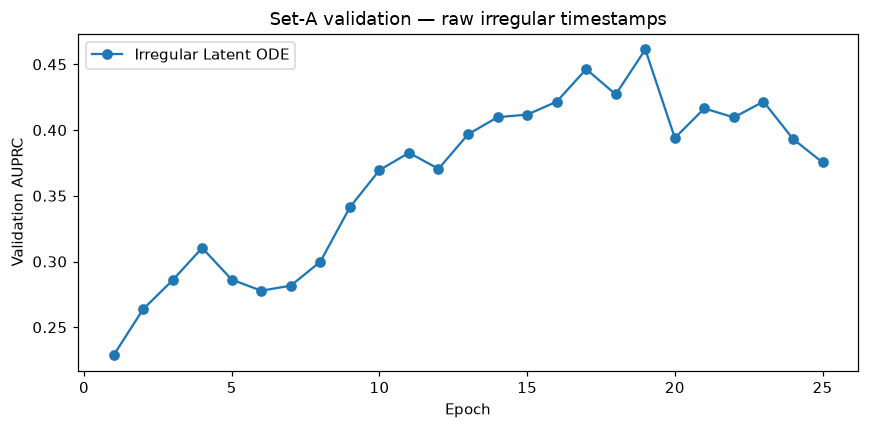

In [28]:
plt.figure(figsize=(8, 4))
plt.plot(
    irregular_hist["epoch"], irregular_hist["val_AUPRC"],
    marker="o", label="Irregular Latent ODE"
)
plt.xlabel("Epoch")
plt.ylabel("Validation AUPRC")
plt.title("Set-A validation — raw irregular timestamps")
plt.legend()
plt.tight_layout()
plt.show()

## 8. Freeze choices and retrain on all A

The epoch count and Event-1 threshold are now frozen. The raw-measurement normalizer is refitted on all of A, then the model is trained from scratch.

In [29]:
final_vocab = build_vocab(A)
final_norm = fit_irregular_normalizer(A, final_vocab)
A_final_ds = IrregularPhysionetDataset(A, final_vocab, final_norm)

torch.manual_seed(SEED)
irregular_final = IrregularLatentODE(
    input_dim=len(final_vocab),
    static_dim=len(STATIC_NAMES),
    latent_dim=16,
    hidden=64,
    max_rk4_step=MAX_RK4_STEP,
)
irregular_final = train_fixed(irregular_final, A_final_ds, irregular_epochs)

print("Final irregular-time model trained on all A.")

01/19 loss=0.8094 time=53.7s
02/19 loss=0.5056 time=54.1s
03/19 loss=0.4912 time=54.8s
04/19 loss=0.4765 time=54.7s
05/19 loss=0.4767 time=54.6s
06/19 loss=0.4588 time=54.6s
07/19 loss=0.4518 time=54.0s
08/19 loss=0.4399 time=55.5s
09/19 loss=0.4360 time=54.9s
10/19 loss=0.4295 time=54.8s
11/19 loss=0.4159 time=54.5s
12/19 loss=0.4023 time=54.6s
13/19 loss=0.4065 time=57.8s
14/19 loss=0.3970 time=56.0s
15/19 loss=0.3921 time=54.8s
16/19 loss=0.3869 time=55.5s
17/19 loss=0.3739 time=56.3s
18/19 loss=0.3572 time=64.3s
19/19 loss=0.3498 time=59.3s
Final irregular-time model trained on all A.


## 9. Load B/C after all choices are frozen

The raw B/C records are transformed using normalization statistics fitted on all A. Their outcome files are still untouched.

In [30]:
B = load_split(RAW_DIR, split="set-b")
C = load_split(RAW_DIR, split="set-c")

assert len(B) == len(C) == 4000
assert all(r.label is None for r in B)
assert all(r.label is None for r in C)

unseen_B = sorted(set(build_vocab(B)) - set(final_vocab))
unseen_C = sorted(set(build_vocab(C)) - set(final_vocab))
assert not unseen_B, f"B variables absent from A vocabulary: {unseen_B}"
assert not unseen_C, f"C variables absent from A vocabulary: {unseen_C}"

B_ds = IrregularPhysionetDataset(B, final_vocab, final_norm)
C_ds = IrregularPhysionetDataset(C, final_vocab, final_norm)

print("B/C loaded as unlabeled raw-timestamp cohorts.")

B/C loaded as unlabeled raw-timestamp cohorts.


## 10. Freeze B/C predictions

After this cell, the information firewall is closed: no preprocessing, architecture, training duration or threshold may be changed using B/C outcomes.

In [31]:
risk_B = predict(irregular_final, B_ds)
risk_C = predict(irregular_final, C_ds)

def submission(records, risk, threshold):
    return pd.DataFrame({
        "RecordID": [str(r.record_id) for r in records],
        "Prediction": (risk >= threshold).astype(int),
        "Risk": risk,
    })

submission_B = submission(B, risk_B, irregular_thr)
submission_C = submission(C, risk_C, irregular_thr)

for df in [submission_B, submission_C]:
    assert len(df) == 4000
    assert df["RecordID"].is_unique
    assert np.isfinite(df["Risk"]).all()
    assert df["Risk"].between(0, 1).all()

print("PREDICTIONS FROZEN. B/C outcomes have not been read up to this point.")
display(submission_C.head())

PREDICTIONS FROZEN. B/C outcomes have not been read up to this point.


,RecordID,Prediction,Risk
0,152871,0,0.135655
1,152873,0,0.001138
2,152875,0,0.005211
3,152878,0,0.038321
4,152882,0,0.001992


## 11. Retrospective B/C scoring — firewall ends here

Released B/C outcomes are now read solely for retrospective scoring. Record IDs are treated as strings and checked for exact alignment.

In [32]:
def read_outcomes(path):
    df = pd.read_csv(path, dtype={"RecordID": str})
    df["RecordID"] = df["RecordID"].str.strip()
    assert df["RecordID"].is_unique, f"Duplicate RecordID in {path.name}"
    return df.set_index("RecordID")["In-hospital_death"]

def aligned_y(records, outcome_map):
    ids = [str(r.record_id).strip() for r in records]
    missing = sorted(set(ids) - set(outcome_map.index))
    extra = sorted(set(outcome_map.index) - set(ids))
    assert not missing, f"Missing outcome IDs: {missing[:10]}"
    assert not extra, f"Outcome IDs without records: {extra[:10]}"
    return np.asarray([int(outcome_map.loc[rid]) for rid in ids], dtype=np.int64)

yB_map = read_outcomes(RAW_DIR / "Outcomes-b.txt")
yC_map = read_outcomes(RAW_DIR / "Outcomes-c.txt")
yB = aligned_y(B, yB_map)
yC = aligned_y(C, yC_map)

irregular_results = pd.DataFrame([
    {
        "Model": "Latent ODE — raw irregular time",
        "Set": "B",
        **metrics(yB, risk_B, irregular_thr),
    },
    {
        "Model": "Latent ODE — raw irregular time",
        "Set": "C",
        **metrics(yC, risk_C, irregular_thr),
    },
])

print("B:", len(yB), "deaths:", yB.sum())
print("C:", len(yC), "deaths:", yC.sum())
display(irregular_results.round(4))

B: 4000 deaths: 568
C: 4000 deaths: 585


,Model,Set,AUROC,AUPRC,Event1,Sensitivity,PPV,Threshold,Event2
0,Latent ODE — raw irregular time,B,0.7862,0.3827,0.3683,0.4630,0.3683,0.2982,7133.6172
1,Latent ODE — raw irregular time,C,0.7834,0.3952,0.3843,0.4855,0.3843,0.2982,7363.6184


## 12. Primary ablation: hourly grid vs raw irregular time

The hourly Latent ODE numbers below are the **frozen results from Notebook 04**. The only newly estimated row is the raw-irregular model above.

This is the primary comparison of Notebook 05.

In [33]:
hourly_latent = pd.DataFrame([
    {
        "Model": "Latent ODE — hourly grid",
        "Set": "B",
        "AUROC": 0.8489, "AUPRC": 0.4850, "Event1": 0.4619,
        "Sensitivity": 0.5757, "PPV": 0.4619,
        "Threshold": 0.3061, "Event2": 34.5598,
    },
    {
        "Model": "Latent ODE — hourly grid",
        "Set": "C",
        "AUROC": 0.8460, "AUPRC": 0.4960, "Event1": 0.4772,
        "Sensitivity": 0.5538, "PPV": 0.4772,
        "Threshold": 0.3061, "Event2": 40.1119,
    },
])

ablation = pd.concat([hourly_latent, irregular_results], ignore_index=True)
display(ablation.round(4))

c_ablation = ablation[ablation["Set"] == "C"].copy()
display(c_ablation.round(4))

,Model,Set,AUROC,AUPRC,Event1,Sensitivity,PPV,Threshold,Event2
0,Latent ODE — hourly grid,B,0.8489,0.4850,0.4619,0.5757,0.4619,0.3061,34.5598
1,Latent ODE — hourly grid,C,0.8460,0.4960,0.4772,0.5538,0.4772,0.3061,40.1119
2,Latent ODE — raw irregular time,B,0.7862,0.3827,0.3683,0.4630,0.3683,0.2982,7133.6172
3,Latent ODE — raw irregular time,C,0.7834,0.3952,0.3843,0.4855,0.3843,0.2982,7363.6184


,Model,Set,AUROC,AUPRC,Event1,Sensitivity,PPV,Threshold,Event2
1,Latent ODE — hourly grid,C,0.8460,0.4960,0.4772,0.5538,0.4772,0.3061,40.1119
3,Latent ODE — raw irregular time,C,0.7834,0.3952,0.3843,0.4855,0.3843,0.2982,7363.6184


## 13. Quantify the Set-C change

Positive deltas in AUROC/AUPRC/Event1 indicate improvement from preserving raw timing. Event 2 is lower-is-better, so its delta is reported separately and should not be interpreted with the same sign convention.

In [34]:
hourly_c = c_ablation[c_ablation["Model"] == "Latent ODE — hourly grid"].iloc[0]
raw_c = c_ablation[c_ablation["Model"] == "Latent ODE — raw irregular time"].iloc[0]

delta = pd.DataFrame([{
    "Comparison": "raw irregular − hourly",
    "Δ AUROC": raw_c["AUROC"] - hourly_c["AUROC"],
    "Δ AUPRC": raw_c["AUPRC"] - hourly_c["AUPRC"],
    "Δ Event1": raw_c["Event1"] - hourly_c["Event1"],
    "Δ Event2": raw_c["Event2"] - hourly_c["Event2"],
}]).set_index("Comparison")

display(delta.round(4))

,Δ AUROC,Δ AUPRC,Δ Event1,Δ Event2
Comparison,,,,
raw irregular − hourly,-0.0626,-0.1008,-0.0929,7323.5065


## 14. Context: all previously frozen Set-C reference models

These rows provide context only. The scientifically controlled ablation is the two-row Latent ODE comparison above.

,Model,AUROC,AUPRC,Event1,Event2
0,Persistence — hourly,0.8518,0.5054,0.4769,1964.5257
1,GRU — hourly,0.8457,0.5165,0.4974,37.0932
2,GRU-D — hourly,0.8391,0.5048,0.4817,377.8176
3,Latent ODE — hourly,0.8460,0.4960,0.4772,40.1119
4,Neural CDE — hourly,0.7475,0.3319,0.3173,217.6957
5,Latent ODE — raw irregular,0.7834,0.3952,0.3843,7363.6184


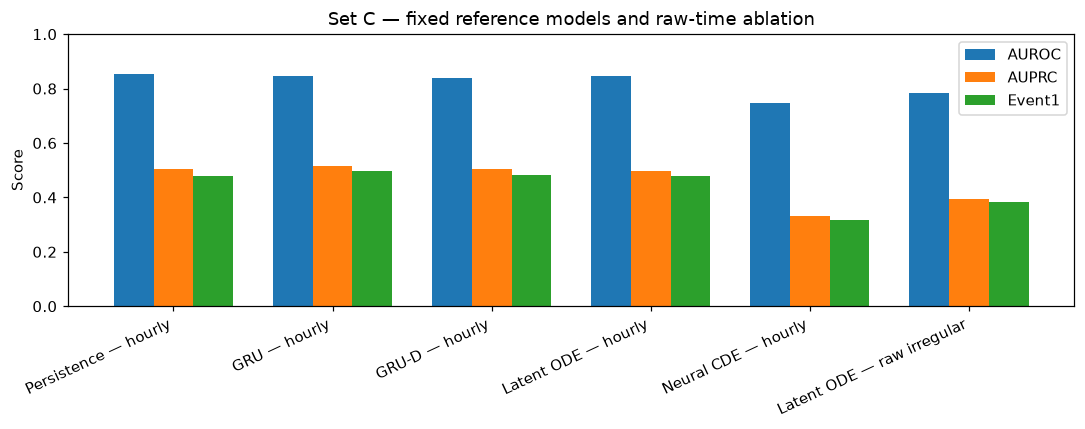

In [35]:
reference_C = pd.DataFrame([
    {"Model":"Persistence — hourly","AUROC":0.8518,"AUPRC":0.5054,"Event1":0.4769,"Event2":1964.5257},
    {"Model":"GRU — hourly","AUROC":0.8457,"AUPRC":0.5165,"Event1":0.4974,"Event2":37.0932},
    {"Model":"GRU-D — hourly","AUROC":0.8391,"AUPRC":0.5048,"Event1":0.4817,"Event2":377.8176},
    {"Model":"Latent ODE — hourly","AUROC":0.8460,"AUPRC":0.4960,"Event1":0.4772,"Event2":40.1119},
    {"Model":"Neural CDE — hourly","AUROC":0.7475,"AUPRC":0.3319,"Event1":0.3173,"Event2":217.6957},
])

raw_row = irregular_results[irregular_results["Set"] == "C"].iloc[0]
reference_C = pd.concat([
    reference_C,
    pd.DataFrame([{
        "Model":"Latent ODE — raw irregular",
        "AUROC":raw_row["AUROC"],
        "AUPRC":raw_row["AUPRC"],
        "Event1":raw_row["Event1"],
        "Event2":raw_row["Event2"],
    }])
], ignore_index=True)

display(reference_C.round(4))

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(reference_C))
w = 0.25
ax.bar(x-w, reference_C["AUROC"], width=w, label="AUROC")
ax.bar(x, reference_C["AUPRC"], width=w, label="AUPRC")
ax.bar(x+w, reference_C["Event1"], width=w, label="Event1")
ax.set_xticks(x)
ax.set_xticklabels(reference_C["Model"], rotation=25, ha="right")
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Set C — fixed reference models and raw-time ablation")
ax.legend()
plt.tight_layout()
plt.show()

## 15. Interpretation guide

This experiment should be interpreted as a **representation ablation**, not as a new leaderboard search.

If the raw-time Latent ODE improves consistently over the hourly Latent ODE on B and C, that supports the hypothesis that preserving measurement timing contains useful predictive information lost by hourly aggregation.

If performance is unchanged, then the hourly grid may already preserve most of the useful temporal signal for this architecture and task.

If performance decreases, that does not by itself show that irregular timing is useless. The raw representation has longer, patient-specific sequences and changes the optimization problem.

### Numerical-method note

This optimized notebook uses **batched fixed-step RK4** with patient-specific raw time intervals, subdividing gaps so that no RK4 step exceeds `MAX_RK4_STEP = 1.0 h`. This is a numerical optimization relative to the first Notebook-05 attempt, which used a separate adaptive `dopri5` solve for every patient. Consequently, the interrupted run's partial epoch history is **not mixed with this run**.

The scientific comparison remains raw irregular timestamps versus the previously frozen hourly-grid Latent ODE. Any future solver-tolerance or RK4-step-size sensitivity analysis must again be selected without using Set C.

No decision in this notebook should be revised after inspecting Set C.

In [36]:
assert len(irregular_results) == 2
assert set(irregular_results["Set"]) == {"B", "C"}
assert np.isfinite(
    irregular_results[["AUROC","AUPRC","Event1","Event2"]].to_numpy()
).all()
assert submission_B["Risk"].between(0,1).all()
assert submission_C["Risk"].between(0,1).all()

print("Notebook 05 completed successfully.")

Notebook 05 completed successfully.
